In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv("/content/Covid_19_Clean_Complete (2).csv")

FileNotFoundError: [Errno 2] No such file or directory: '/content/Covid_19_Clean_Complete (2).csv'

In [ ]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [ ]:
df.isnull().sum()

,0
Province/State,34404
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [ ]:
df["Province/State"].value_counts()

,count
Province/State,
Australian Capital Territory,188
New South Wales,188
Northern Territory,188
Queensland,188
South Australia,188
...,...
Anguilla,188
British Virgin Islands,188
Turks and Caicos Islands,188


In [ ]:
df.shape

(49068, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [ ]:
df.rename(columns = {
    "Province/State" : "state",
    "Country/Region" : "country"
},inplace = True)

In [ ]:
df

,state,country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


# Confirm Cases

In [ ]:
confirmed_cases = df.groupby(["Date"])["Confirmed"].sum().reset_index()
confirmed_cases

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


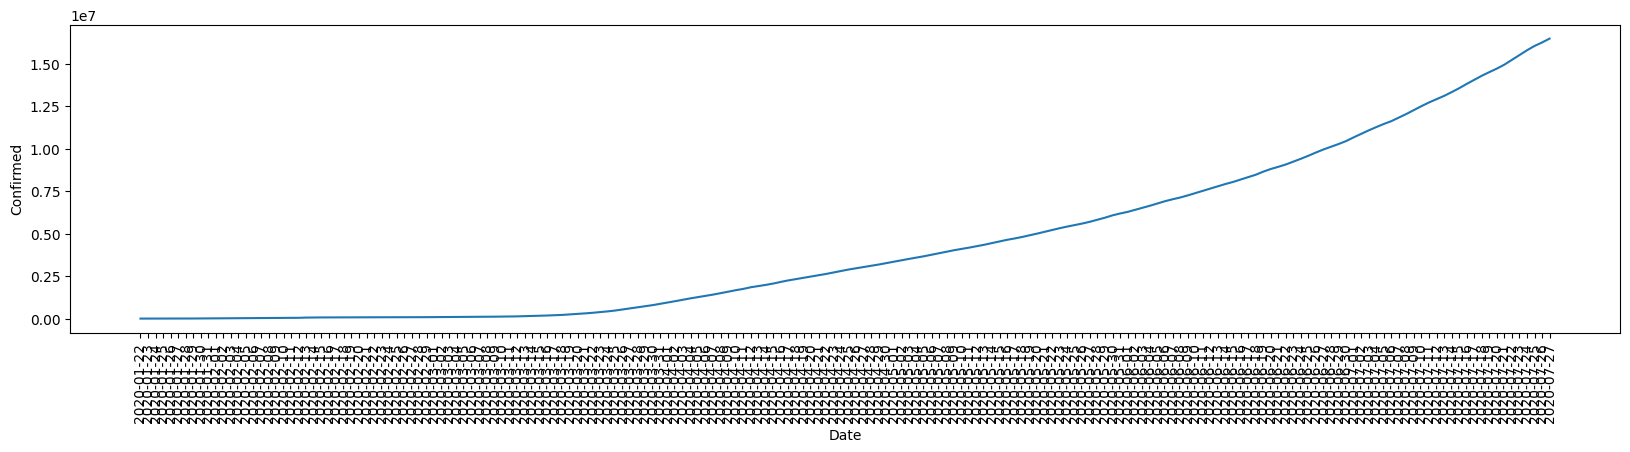

In [ ]:
plt.figure(figsize=(20,4))
sns.lineplot(data = confirmed_cases, x = "Date", y = "Confirmed")
plt.xticks(rotation = 90)
plt.show()

# Death Cases

In [ ]:
death_cases = df.groupby(["Date"])["Deaths"].sum().reset_index()
death_cases

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


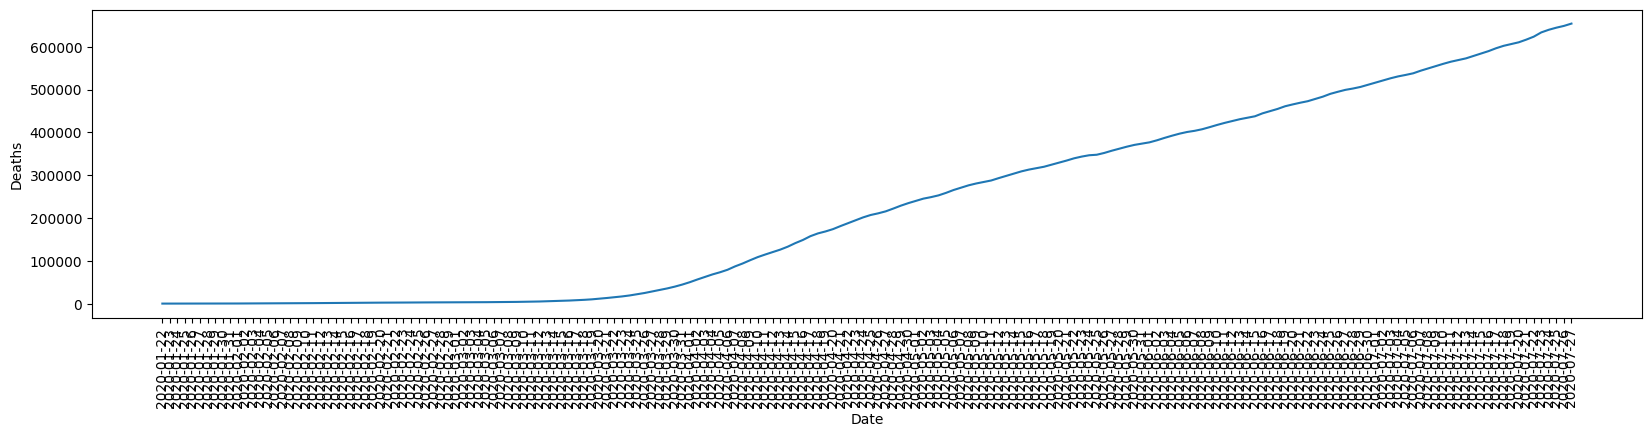

In [ ]:
plt.figure(figsize=(20,4))
sns.lineplot(data=death_cases, x="Date", y="Deaths")
plt.xticks(rotation=90)
plt.show()

# Recovered Cases

In [ ]:
Recovered_Cases = df.groupby(["Date"])["Recovered"].sum().reset_index()
Recovered_Cases

,Date,Recovered
0,2020-01-22,28
1,2020-01-23,30
2,2020-01-24,36
3,2020-01-25,39
4,2020-01-26,52
...,...,...
183,2020-07-23,8710969
184,2020-07-24,8939705
185,2020-07-25,9158743
186,2020-07-26,9293464


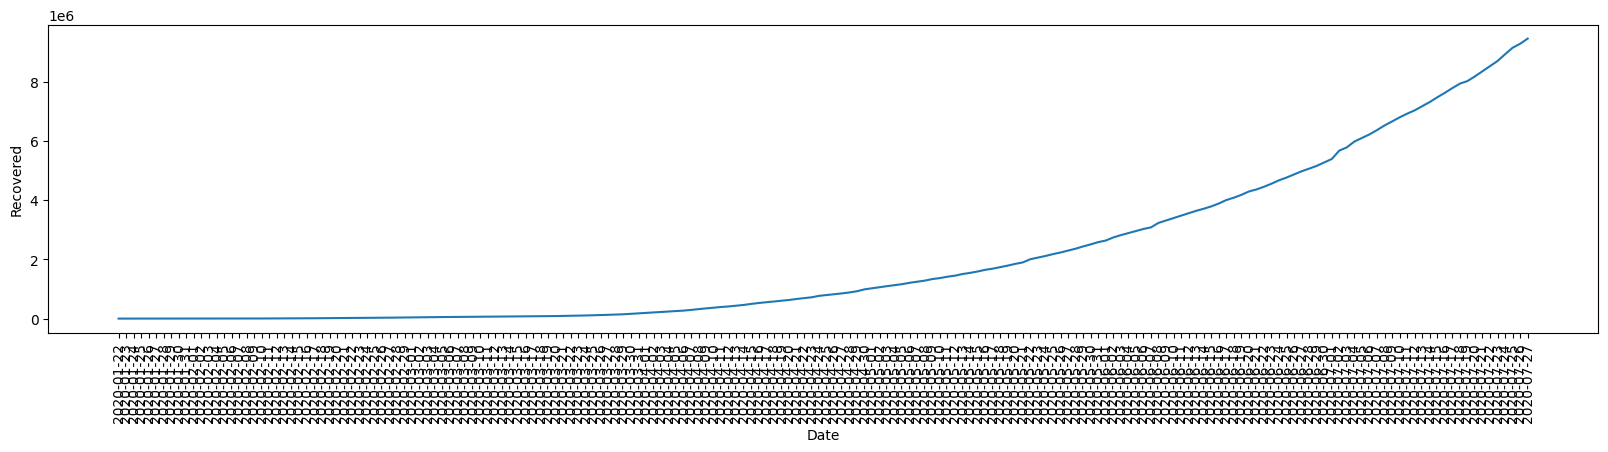

In [ ]:
plt.figure(figsize = (20,4))
sns.lineplot(data=Recovered_Cases, x="Date", y="Recovered")
plt.xticks(rotation=90)
plt.show()

# Active Cases

In [ ]:
Active_cases = df.groupby(["Date"])["Active"].sum().reset_index()
Active_cases

,Date,Active
0,2020-01-22,510
1,2020-01-23,606
2,2020-01-24,879
3,2020-01-25,1353
4,2020-01-26,2010
...,...,...
183,2020-07-23,6166006
184,2020-07-24,6212290
185,2020-07-25,6243930
186,2020-07-26,6309711


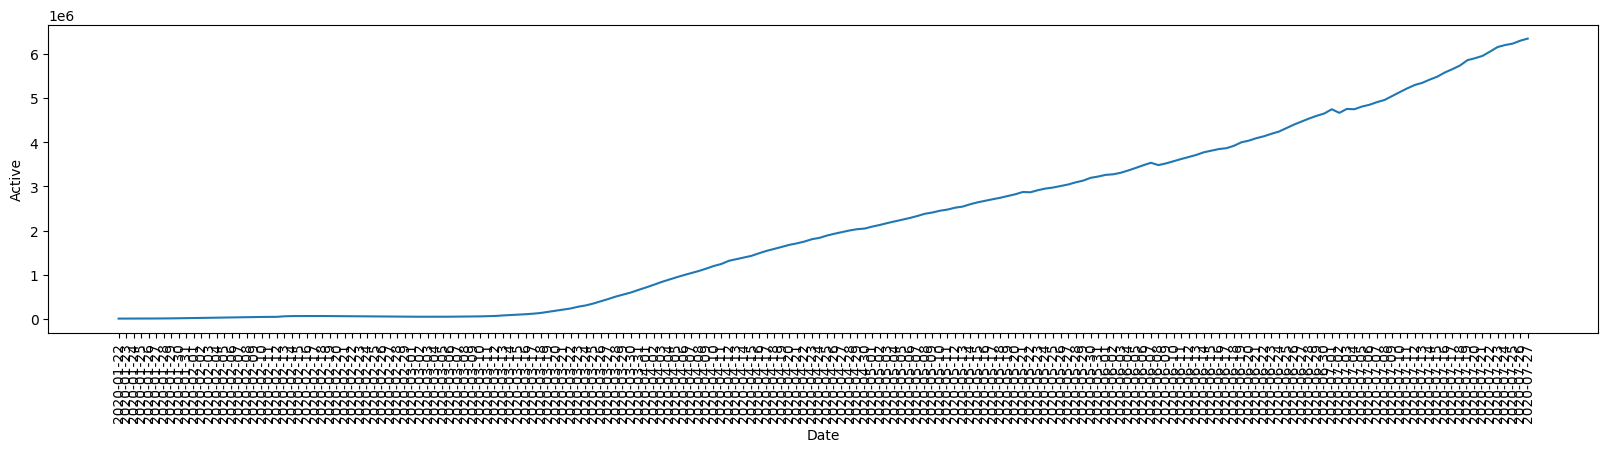

In [ ]:
plt.figure(figsize=(20,4))
sns.lineplot(data=Active_cases, x="Date", y="Active")
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Lets find most affected countries

In [ ]:
df.columns

Index(['state', 'country', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths',
       'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [ ]:
data_countries = df.groupby(["country"])[[ 'Confirmed', 'Deaths','Recovered', 'Active']].sum().reset_index()
data_countries

,country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,1936390,49098,798240,1089052
1,Albania,196702,5708,118877,72117
2,Algeria,1179755,77972,755897,345886
3,Andorra,94404,5423,69074,19907
4,Angola,22662,1078,6573,15011
...,...,...,...,...,...
182,West Bank and Gaza,233461,1370,61124,170967
183,Western Sahara,901,63,648,190
184,Yemen,67180,17707,23779,25694
185,Zambia,129421,2643,83611,43167


In [ ]:
# Top 3 Countries

In [ ]:
top3_confirmed = data_countries.sort_values(by="Confirmed", ascending=False).head(3)
top3_confirmed

,country,Confirmed,Deaths,Recovered,Active
173,US,224345948,11011411,56353416,156981121
23,Brazil,89524967,3938034,54492873,31094060
138,Russia,45408411,619385,25120448,19668578


In [ ]:
top3_Deaths = data_countries.sort_values(by="Deaths", ascending=False).head(3)
top3_Deaths

,country,Confirmed,Deaths,Recovered,Active
173,US,224345948,11011411,56353416,156981121
177,United Kingdom,26748587,3997775,126217,22624595
23,Brazil,89524967,3938034,54492873,31094060


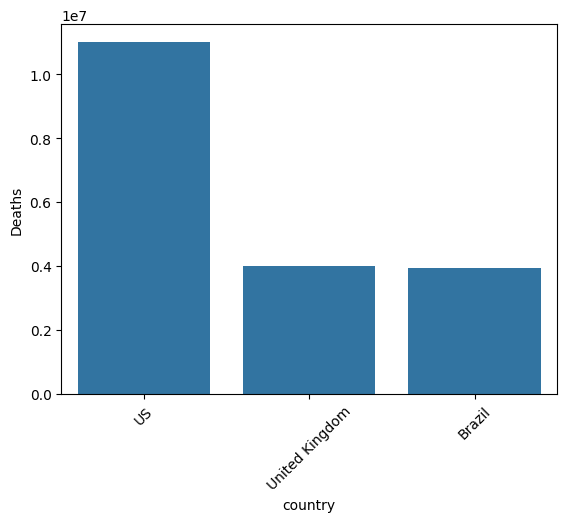

In [ ]:
sns.barplot(data = top3_Deaths ,x ="country" , y="Deaths")
plt.xticks(rotation=45)
plt.show()

In [ ]:
top3_Recovered = data_countries.sort_values(by="Recovered", ascending=False).head(3)
top3_Recovered

,country,Confirmed,Deaths,Recovered,Active
173,US,224345948,11011411,56353416,156981121
23,Brazil,89524967,3938034,54492873,31094060
138,Russia,45408411,619385,25120448,19668578


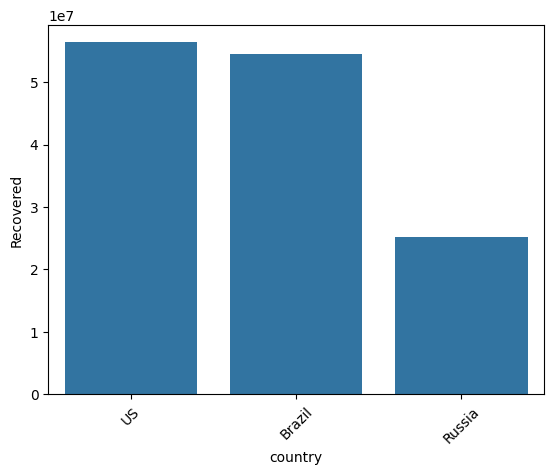

In [ ]:
sns.barplot(data = top3_Recovered ,x ="country" , y="Recovered")
plt.xticks(rotation=45)
plt.show()

In [ ]:
top3_Active = data_countries.sort_values(by="Active", ascending=False).head(3)
top3_Active

,country,Confirmed,Deaths,Recovered,Active
173,US,224345948,11011411,56353416,156981121
23,Brazil,89524967,3938034,54492873,31094060
177,United Kingdom,26748587,3997775,126217,22624595


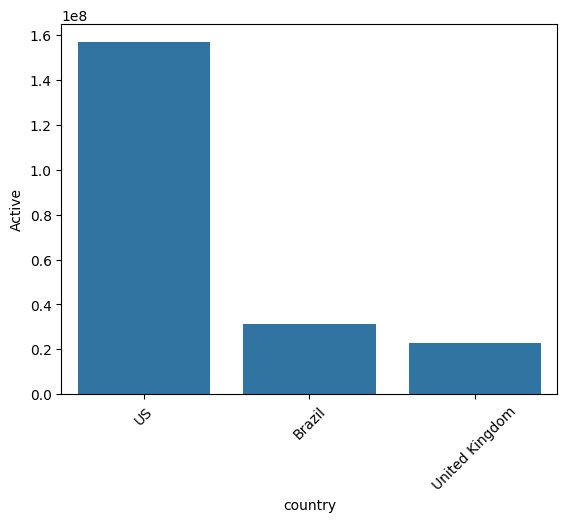

In [ ]:
sns.barplot(data = top3_Active ,x ="country" , y="Active")
plt.xticks(rotation=45)
plt.show()

In [ ]:
us = df[df['country'] == "US"]
us

,state,country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
223,NaN,US,40.0,-100.0,2020-01-22,1,0,0,1,Americas
484,NaN,US,40.0,-100.0,2020-01-23,1,0,0,1,Americas
745,NaN,US,40.0,-100.0,2020-01-24,2,0,0,2,Americas
1006,NaN,US,40.0,-100.0,2020-01-25,2,0,0,2,Americas
1267,NaN,US,40.0,-100.0,2020-01-26,5,0,0,5,Americas
...,...,...,...,...,...,...,...,...,...,...
47986,NaN,US,40.0,-100.0,2020-07-23,4038816,144430,1233269,2661117,Americas
48247,NaN,US,40.0,-100.0,2020-07-24,4112531,145560,1261624,2705347,Americas
48508,NaN,US,40.0,-100.0,2020-07-25,4178970,146465,1279414,2753091,Americas
48769,NaN,US,40.0,-100.0,2020-07-26,4233923,146935,1297863,2789125,Americas


In [ ]:
data_us = us.groupby(["Date"])[[ 'Confirmed', 'Deaths','Recovered', 'Active']].sum().reset_index()
data_us

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,1,0,0,1
1,2020-01-23,1,0,0,1
2,2020-01-24,2,0,0,2
3,2020-01-25,2,0,0,2
4,2020-01-26,5,0,0,5
...,...,...,...,...,...
183,2020-07-23,4038816,144430,1233269,2661117
184,2020-07-24,4112531,145560,1261624,2705347
185,2020-07-25,4178970,146465,1279414,2753091
186,2020-07-26,4233923,146935,1297863,2789125


In [ ]:
Brazil = df[df['country'] == "Brazil"]
Brazil

,state,country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
28,NaN,Brazil,-14.235,-51.9253,2020-01-22,0,0,0,0,Americas
289,NaN,Brazil,-14.235,-51.9253,2020-01-23,0,0,0,0,Americas
550,NaN,Brazil,-14.235,-51.9253,2020-01-24,0,0,0,0,Americas
811,NaN,Brazil,-14.235,-51.9253,2020-01-25,0,0,0,0,Americas
1072,NaN,Brazil,-14.235,-51.9253,2020-01-26,0,0,0,0,Americas
...,...,...,...,...,...,...,...,...,...,...
47791,NaN,Brazil,-14.235,-51.9253,2020-07-23,2287475,84082,1620313,583080,Americas
48052,NaN,Brazil,-14.235,-51.9253,2020-07-24,2343366,85238,1693214,564914,Americas
48313,NaN,Brazil,-14.235,-51.9253,2020-07-25,2394513,86449,1785359,522705,Americas
48574,NaN,Brazil,-14.235,-51.9253,2020-07-26,2419091,87004,1812913,519174,Americas


In [ ]:
data_Brazil = Brazil.groupby(["Date"])[[ 'Confirmed', 'Deaths','Recovered', 'Active']].sum().reset_index()
data_Brazil

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,2287475,84082,1620313,583080
184,2020-07-24,2343366,85238,1693214,564914
185,2020-07-25,2394513,86449,1785359,522705
186,2020-07-26,2419091,87004,1812913,519174


In [ ]:
Russia = df[df['country'] == "Russia"]
Russia

,state,country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
185,NaN,Russia,61.52401,105.318756,2020-01-22,0,0,0,0,Europe
446,NaN,Russia,61.52401,105.318756,2020-01-23,0,0,0,0,Europe
707,NaN,Russia,61.52401,105.318756,2020-01-24,0,0,0,0,Europe
968,NaN,Russia,61.52401,105.318756,2020-01-25,0,0,0,0,Europe
1229,NaN,Russia,61.52401,105.318756,2020-01-26,0,0,0,0,Europe
...,...,...,...,...,...,...,...,...,...,...
47948,NaN,Russia,61.52401,105.318756,2020-07-23,793720,12873,579295,201552,Europe
48209,NaN,Russia,61.52401,105.318756,2020-07-24,799499,13026,587728,198745,Europe
48470,NaN,Russia,61.52401,105.318756,2020-07-25,805332,13172,596064,196096,Europe
48731,NaN,Russia,61.52401,105.318756,2020-07-26,811073,13249,599172,198652,Europe


In [ ]:
data_Russia = Russia.groupby(["Date"])[[ 'Confirmed', 'Deaths','Recovered', 'Active']].sum().reset_index()
data_Russia

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,793720,12873,579295,201552
184,2020-07-24,799499,13026,587728,198745
185,2020-07-25,805332,13172,596064,196096
186,2020-07-26,811073,13249,599172,198652


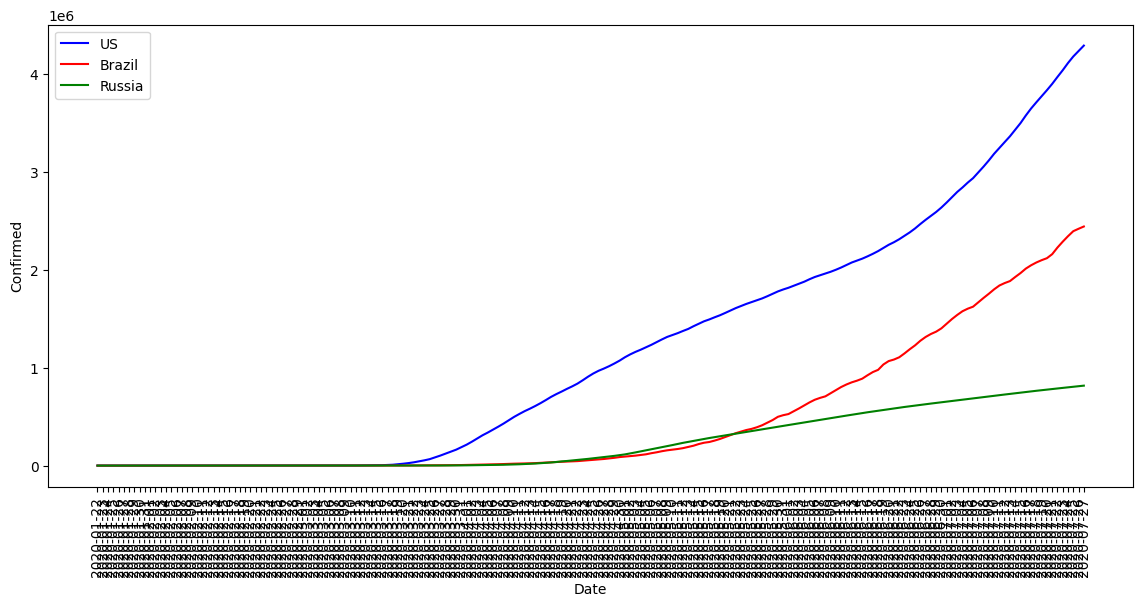

In [ ]:
plt.figure(figsize=(14,6))
sns.lineplot(data = data_us, x="Date",y="Confirmed",color= "blue",label="US")
sns.lineplot(data = data_Brazil, x="Date",y="Confirmed",color= "red",label="Brazil")
sns.lineplot(data = data_Russia, x="Date",y="Confirmed",color= "green",label="Russia")
plt.xticks(rotation=90)
plt.show()

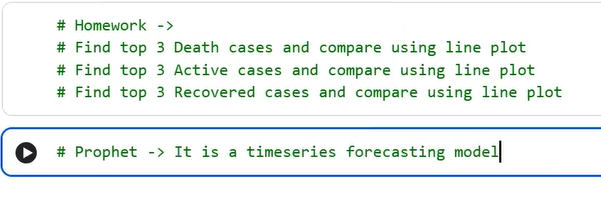

# Import Prophet developed by meta(Facebook)

In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet

# Forecasting for a confirmed cases

In [ ]:
confirmed_cases = df.groupby("Date")["Confirmed"].sum().reset_index()

In [ ]:
confirmed_cases

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [ ]:
# We need to rename the column as ds(datestamp) and y(value)
prophet_data = confirmed_cases.rename(columns={
    "Date" : "ds",
    "Confirmed" : "y"
})


In [ ]:
prophet_data

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [ ]:
model = Prophet()

In [ ]:
model.fit(prophet_data)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
Future_confirmed =  model.make_future_dataframe(periods=7) # for future 7 days

In [ ]:
Future_confirmed

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02


In [ ]:
forecast_confirmed = model.predict(Future_confirmed)
forecast_confirmed

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9.613288e+03,-1.212025e+05,7.837557e+04,-9.613288e+03,-9.613288e+03,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,0.0,0.0,0.0,-2.067685e+04
1,2020-01-23,-6.933409e+03,-1.088696e+05,9.648785e+04,-6.933409e+03,-6.933409e+03,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,-8.050953e+03
2,2020-01-24,-4.253530e+03,-1.040176e+05,1.089570e+05,-4.253530e+03,-4.253530e+03,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,5.827449e+03
3,2020-01-25,-1.573651e+03,-9.673776e+04,1.143654e+05,-1.573651e+03,-1.573651e+03,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.217668e+04
4,2020-01-26,1.106228e+03,-8.934439e+04,1.153763e+05,1.106228e+03,1.106228e+03,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,8.405020e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,1.674503e+07,1.663608e+07,1.684970e+07,1.673994e+07,1.674884e+07,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,1.674392e+07
191,2020-07-31,1.694902e+07,1.685091e+07,1.705849e+07,1.693623e+07,1.695830e+07,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,1.695911e+07
192,2020-08-01,1.715301e+07,1.705709e+07,1.727800e+07,1.713025e+07,1.717206e+07,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.716677e+07
193,2020-08-02,1.735701e+07,1.724073e+07,1.747292e+07,1.732365e+07,1.738396e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.736430e+07


In [ ]:
forecast_confirmed[["yhat_lower","yhat_upper","yhat"]]

,yhat_lower,yhat_upper,yhat
0,-1.212025e+05,7.837557e+04,-2.067685e+04
1,-1.088696e+05,9.648785e+04,-8.050953e+03
2,-1.040176e+05,1.089570e+05,5.827449e+03
3,-9.673776e+04,1.143654e+05,1.217668e+04
4,-8.934439e+04,1.153763e+05,8.405020e+03
...,...,...,...
190,1.663608e+07,1.684970e+07,1.674392e+07
191,1.685091e+07,1.705849e+07,1.695911e+07
192,1.705709e+07,1.727800e+07,1.716677e+07
193,1.724073e+07,1.747292e+07,1.736430e+07


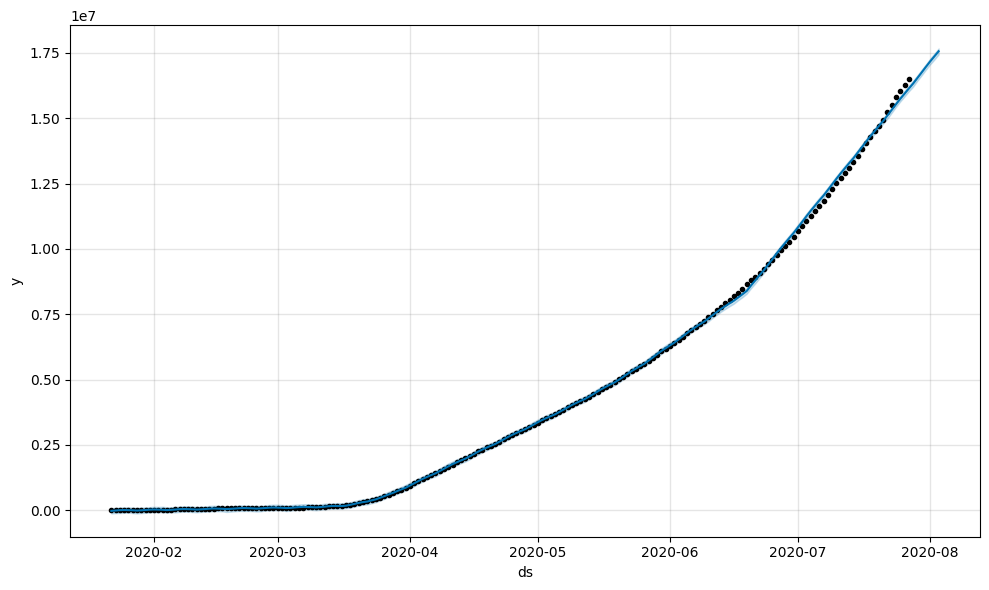

In [ ]:
model.plot(forecast_confirmed)
plt.show()

# Forecasting for a Death cases

In [ ]:
Deaths_cases = df.groupby("Date")["Deaths"].sum().reset_index()

In [ ]:
Deaths_cases

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


In [ ]:
# WE need to convert Date and Death column name into  ds(datestamp) and y(value-target)
prophet1_data = Deaths_cases.rename(columns={
    "Date" : "ds",
    "Deaths" : "y"
})

In [ ]:
prophet1_data

,ds,y
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


In [ ]:
model1 = Prophet()

In [ ]:
model1.fit(prophet1_data)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future_Death = model1.make_future_dataframe(periods=7,freq="D")

In [ ]:
future_Death

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02


In [ ]:
forecast_Death = model1.predict(future_Death)
forecast_Death

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-522.113185,-2730.570009,1243.747168,-522.113185,-522.113185,-191.187755,-191.187755,-191.187755,-191.187755,-191.187755,-191.187755,0.0,0.0,0.0,-713.300939
1,2020-01-23,-432.419342,-1934.432594,2064.669772,-432.419342,-432.419342,388.672065,388.672065,388.672065,388.672065,388.672065,388.672065,0.0,0.0,0.0,-43.747277
2,2020-01-24,-342.725499,-1417.424920,2483.399084,-342.725499,-342.725499,874.264079,874.264079,874.264079,874.264079,874.264079,874.264079,0.0,0.0,0.0,531.538580
3,2020-01-25,-253.031656,-1489.615489,2486.402707,-253.031656,-253.031656,726.889465,726.889465,726.889465,726.889465,726.889465,726.889465,0.0,0.0,0.0,473.857809
4,2020-01-26,-163.337813,-2230.985325,1594.866803,-163.337813,-163.337813,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,0.0,0.0,0.0,-328.938272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,663102.734264,661634.704704,665580.655971,662878.246409,663391.976483,388.672065,388.672065,388.672065,388.672065,388.672065,388.672065,0.0,0.0,0.0,663491.406328
191,2020-07-31,668132.143204,666739.743053,671308.264624,667627.336569,668675.045087,874.264079,874.264079,874.264079,874.264079,874.264079,874.264079,0.0,0.0,0.0,669006.407283
192,2020-08-01,673161.552144,671374.503669,676360.436909,672327.511704,674197.146039,726.889465,726.889465,726.889465,726.889465,726.889465,726.889465,0.0,0.0,0.0,673888.441609
193,2020-08-02,678190.961084,675448.358347,680706.280816,676862.690779,679699.019427,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,0.0,0.0,0.0,678025.360624


In [ ]:
forecast_Death[["yhat_lower","yhat_upper","yhat"]]

,yhat_lower,yhat_upper,yhat
0,-2730.570009,1243.747168,-713.300939
1,-1934.432594,2064.669772,-43.747277
2,-1417.424920,2483.399084,531.538580
3,-1489.615489,2486.402707,473.857809
4,-2230.985325,1594.866803,-328.938272
...,...,...,...
190,661634.704704,665580.655971,663491.406328
191,666739.743053,671308.264624,669006.407283
192,671374.503669,676360.436909,673888.441609
193,675448.358347,680706.280816,678025.360624


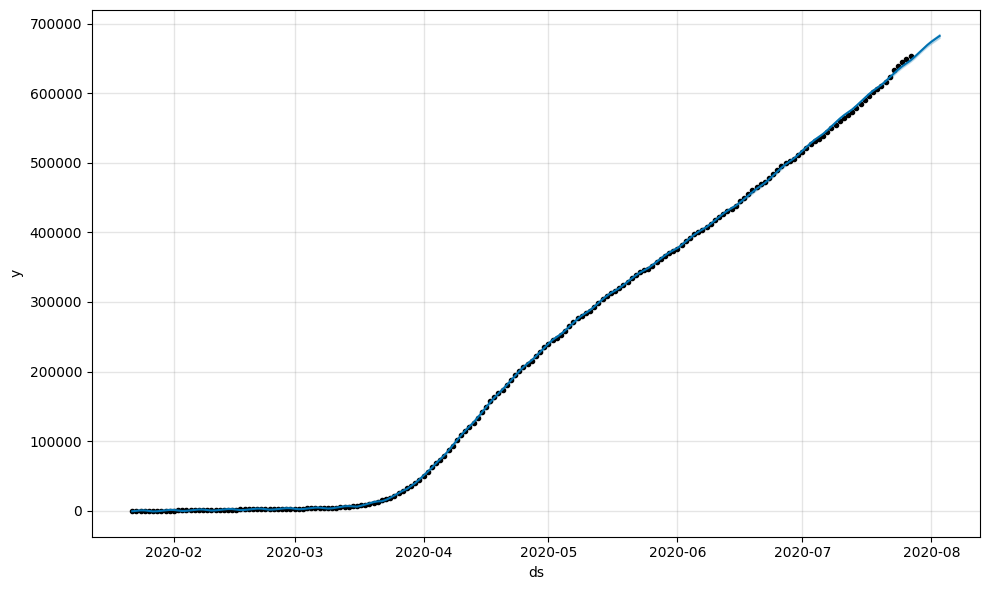

In [ ]:
model1.plot(forecast_Death)
plt.show()

# Forecast for a Recovered Cases

In [ ]:
Recovered_cases = df.groupby("Date")["Recovered"].sum().reset_index()

In [ ]:
Recovered_cases

,Date,Recovered
0,2020-01-22,28
1,2020-01-23,30
2,2020-01-24,36
3,2020-01-25,39
4,2020-01-26,52
...,...,...
183,2020-07-23,8710969
184,2020-07-24,8939705
185,2020-07-25,9158743
186,2020-07-26,9293464


In [ ]:
# WE need to convert Date and Death column name into  ds(datestamp) and y(value-target)
prophet2_data = Recovered_cases.rename(columns={
    "Date" : "ds",
    "Recovered" : "y"
})

In [ ]:
prophet2_data

,ds,y
0,2020-01-22,28
1,2020-01-23,30
2,2020-01-24,36
3,2020-01-25,39
4,2020-01-26,52
...,...,...
183,2020-07-23,8710969
184,2020-07-24,8939705
185,2020-07-25,9158743
186,2020-07-26,9293464


In [ ]:
model2 = Prophet()

In [ ]:
model2.fit(prophet2_data)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future_Recovered = model2.make_future_dataframe(periods=7)

In [ ]:
future_Recovered

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02


In [ ]:
forecast_Recovered = model2.predict(future_Recovered)
forecast_Recovered

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-1.360144e+04,-9.535189e+04,6.257275e+04,-1.360144e+04,-1.360144e+04,-4840.633687,-4840.633687,-4840.633687,-4840.633687,-4840.633687,-4840.633687,0.0,0.0,0.0,-1.844208e+04
1,2020-01-23,-1.243662e+04,-9.019072e+04,6.475341e+04,-1.243662e+04,-1.243662e+04,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,0.0,0.0,0.0,-1.118182e+04
2,2020-01-24,-1.127180e+04,-8.621422e+04,6.940223e+04,-1.127180e+04,-1.127180e+04,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,0.0,0.0,0.0,-5.175647e+03
3,2020-01-25,-1.010697e+04,-7.978435e+04,8.162791e+04,-1.010697e+04,-1.010697e+04,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,0.0,0.0,0.0,-4.075311e+02
4,2020-01-26,-8.942151e+03,-8.685660e+04,6.605987e+04,-8.942151e+03,-8.942151e+03,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,0.0,0.0,0.0,-9.825630e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,9.594538e+06,9.517391e+06,9.674226e+06,9.591175e+06,9.597044e+06,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,0.0,0.0,0.0,9.595793e+06
191,2020-07-31,9.731096e+06,9.661327e+06,9.815396e+06,9.724416e+06,9.737438e+06,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,0.0,0.0,0.0,9.737193e+06
192,2020-08-01,9.867654e+06,9.792034e+06,9.964652e+06,9.856112e+06,9.879067e+06,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,0.0,0.0,0.0,9.877354e+06
193,2020-08-02,1.000421e+07,9.919254e+06,1.008668e+07,9.986563e+06,1.002243e+07,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,0.0,0.0,0.0,1.000333e+07


In [ ]:
forecast_Recovered[["yhat_lower","yhat_upper","yhat"]]

,yhat_lower,yhat_upper,yhat
0,-9.535189e+04,6.257275e+04,-1.844208e+04
1,-9.019072e+04,6.475341e+04,-1.118182e+04
2,-8.621422e+04,6.940223e+04,-5.175647e+03
3,-7.978435e+04,8.162791e+04,-4.075311e+02
4,-8.685660e+04,6.605987e+04,-9.825630e+03
...,...,...,...
190,9.517391e+06,9.674226e+06,9.595793e+06
191,9.661327e+06,9.815396e+06,9.737193e+06
192,9.792034e+06,9.964652e+06,9.877354e+06
193,9.919254e+06,1.008668e+07,1.000333e+07


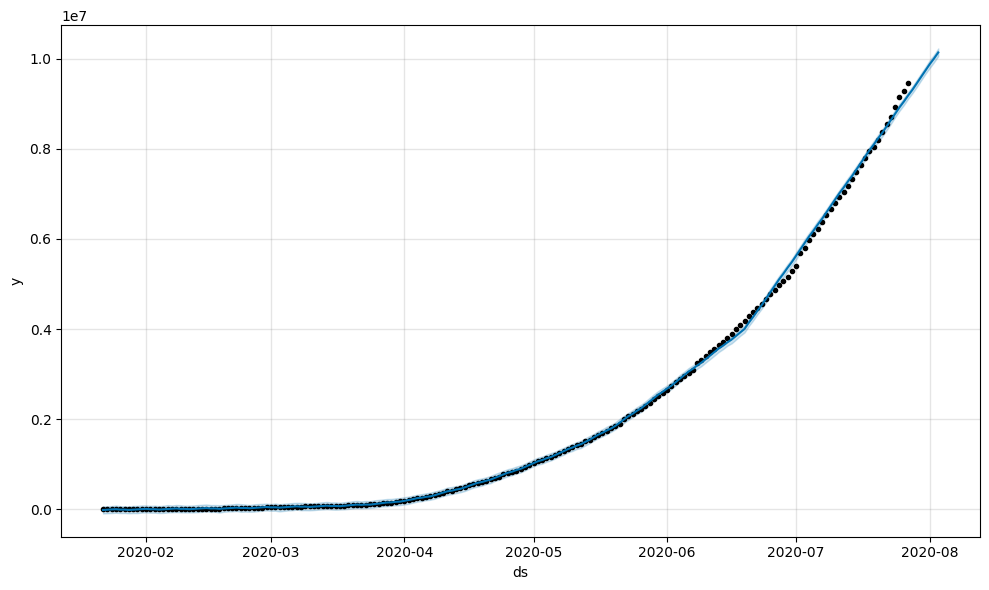

In [ ]:
model2.plot(forecast_Recovered)
plt.show()

# Forecast for Active Cases

In [ ]:
Active_cases = df.groupby("Date")["Active"].sum().reset_index()

In [ ]:
Active_cases

,Date,Active
0,2020-01-22,510
1,2020-01-23,606
2,2020-01-24,879
3,2020-01-25,1353
4,2020-01-26,2010
...,...,...
183,2020-07-23,6166006
184,2020-07-24,6212290
185,2020-07-25,6243930
186,2020-07-26,6309711


In [ ]:
# WE need to convert Date and Death column name into  ds(datestamp) and y(value-target)
prophet3_data = Active_cases.rename(columns={
    "Date" : "ds",
    "Active" : "y"
})

In [ ]:
prophet3_data

,ds,y
0,2020-01-22,510
1,2020-01-23,606
2,2020-01-24,879
3,2020-01-25,1353
4,2020-01-26,2010
...,...,...
183,2020-07-23,6166006
184,2020-07-24,6212290
185,2020-07-25,6243930
186,2020-07-26,6309711


In [ ]:
model3 = Prophet()

In [ ]:
model3.fit(prophet3_data)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future_Active = model3.make_future_dataframe(periods=7)

In [ ]:
future_Active

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02


In [ ]:
forecast_Active = model3.predict(future_Active)
forecast_Active

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-5.051891e+02,-5.392021e+04,3.826753e+04,-5.051891e+02,-5.051891e+02,-5734.815309,-5734.815309,-5734.815309,-5734.815309,-5734.815309,-5734.815309,0.0,0.0,0.0,-6.240004e+03
1,2020-01-23,1.357197e+03,-4.990159e+04,4.570656e+04,1.357197e+03,1.357197e+03,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,0.0,0.0,0.0,-1.186218e+03
2,2020-01-24,3.219584e+03,-3.939363e+04,5.006929e+04,3.219584e+03,3.219584e+03,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,0.0,0.0,0.0,6.450369e+03
3,2020-01-25,5.081970e+03,-3.838454e+04,5.040147e+04,5.081970e+03,5.081970e+03,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,0.0,0.0,0.0,8.209977e+03
4,2020-01-26,6.944356e+03,-3.105048e+04,6.100485e+04,6.944356e+03,6.944356e+03,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,0.0,0.0,0.0,1.509627e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,6.483822e+06,6.437092e+06,6.527571e+06,6.480556e+06,6.486181e+06,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,0.0,0.0,0.0,6.481279e+06
191,2020-07-31,6.546090e+06,6.500982e+06,6.595113e+06,6.539787e+06,6.551381e+06,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,0.0,0.0,0.0,6.549320e+06
192,2020-08-01,6.608357e+06,6.566140e+06,6.656188e+06,6.598624e+06,6.617169e+06,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,0.0,0.0,0.0,6.611485e+06
193,2020-08-02,6.670624e+06,6.631310e+06,6.725764e+06,6.656824e+06,6.683603e+06,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,0.0,0.0,0.0,6.678776e+06


In [ ]:
forecast_Active[["yhat_lower","yhat_upper","yhat"]]

,yhat_lower,yhat_upper,yhat
0,-5.392021e+04,3.826753e+04,-6.240004e+03
1,-4.990159e+04,4.570656e+04,-1.186218e+03
2,-3.939363e+04,5.006929e+04,6.450369e+03
3,-3.838454e+04,5.040147e+04,8.209977e+03
4,-3.105048e+04,6.100485e+04,1.509627e+04
...,...,...,...
190,6.437092e+06,6.527571e+06,6.481279e+06
191,6.500982e+06,6.595113e+06,6.549320e+06
192,6.566140e+06,6.656188e+06,6.611485e+06
193,6.631310e+06,6.725764e+06,6.678776e+06


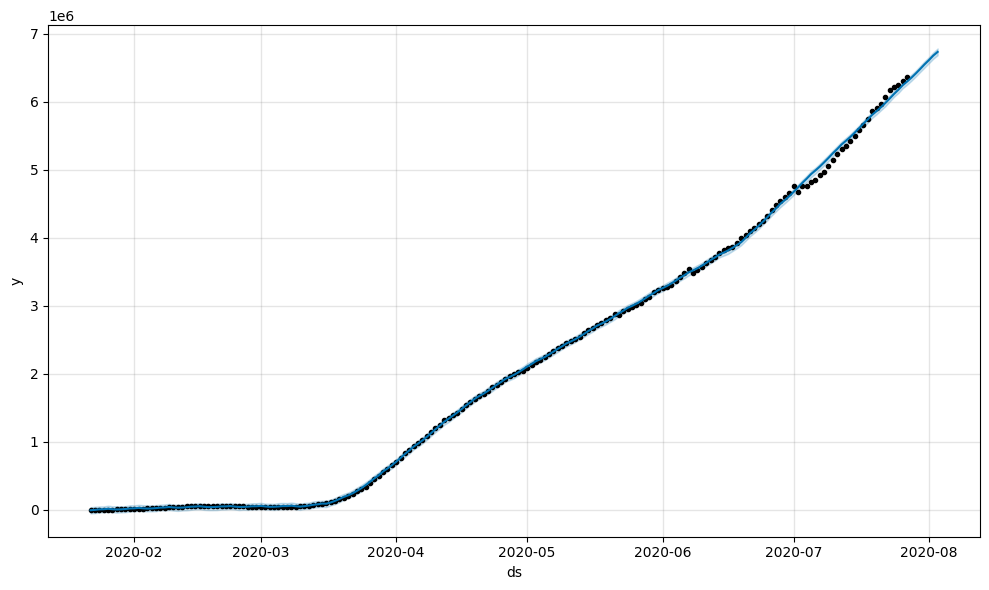

In [ ]:
model3.plot(forecast_Active)
plt.show()